In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from dwave_simulator import DwaveSimulator

In [2]:
sim = DwaveSimulator()

In [3]:
problem = sim.generate_random_ising_problem(
    n=5,
    weight_min=-1.0,
    weight_max=1.0,
    random_seed=42
)

print("Noisy test problem:")
print(problem)

Noisy test problem:
0.951244703273512*x1*x2 + 0.522279403980706*x1*x3 + 0.572128610553908*x1*x4 - 0.743772734648908*x1*x5 + 0.547912097111927*x1 - 0.0992281242088657*x2*x3 - 0.258403951534838*x2*x4 + 0.853529977697204*x2*x5 - 0.122243120495895*x2 + 0.287730240161329*x3*x4 + 0.64552322654166*x3*x5 + 0.717195839822765*x3 - 0.113171602345338*x4*x5 + 0.394736058118728*x4 - 0.811645304224701*x5


In [4]:
eig_hist_noisy, vec_hist_noisy = sim.simulate_noisy_evolution(
    problem,
    nb_eigenvalues=5,
    noise_std=0.1,
    random_seed=42
)

print("First step eigenvalues:")
print(eig_hist_noisy[0])

print("Last step eigenvalues:")
print(eig_hist_noisy[-1])

First step eigenvalues:
[-5. -3. -3. -3. -3.]
Last step eigenvalues:
[-7.09941541 -7.01097798 -5.22696898 -5.02468487 -4.70026672]


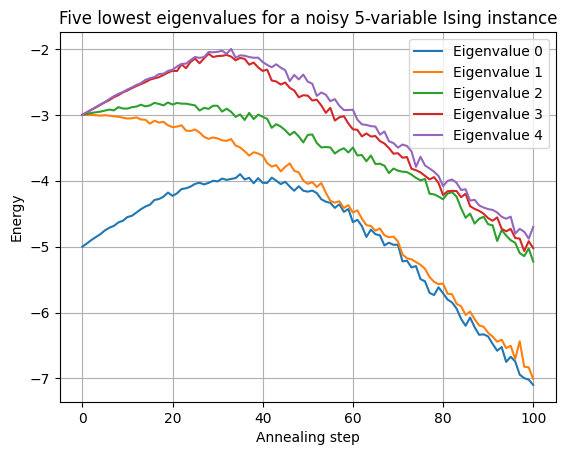

In [5]:
sim.plot_eigenvalues(
    eig_hist_noisy,
    title="Five lowest eigenvalues for a noisy 5-variable Ising instance"
)

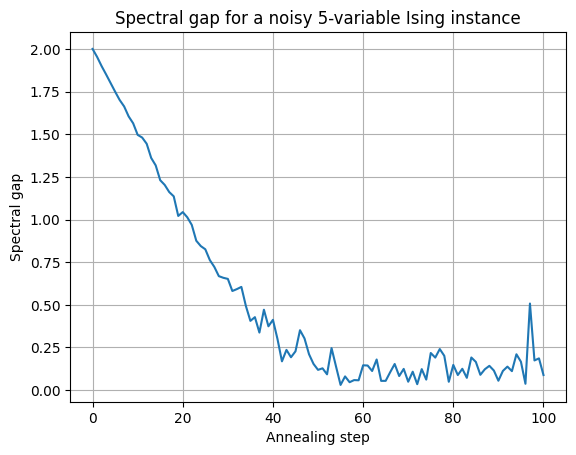

Minimum noisy gap: 0.03043265763915759
Step of minimum noisy gap: 55


In [6]:
gap_noisy = sim.plot_spectral_gap(
    eig_hist_noisy,
    title="Spectral gap for a noisy 5-variable Ising instance"
)

print("Minimum noisy gap:", gap_noisy.min())
print("Step of minimum noisy gap:", gap_noisy.argmin())

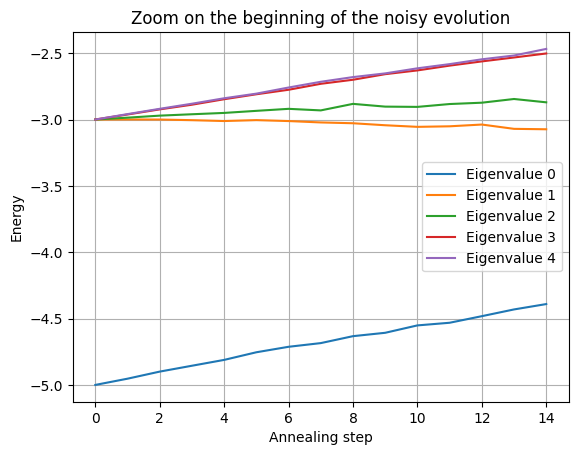

In [7]:
eig_array = np.array(eig_hist_noisy, dtype=float)

plt.figure()
for i in range(5):
    plt.plot(eig_array[:15, i], label=f"Eigenvalue {i}")
plt.xlabel("Annealing step")
plt.ylabel("Energy")
plt.title("Zoom on the beginning of the noisy evolution")
plt.legend()
plt.grid(True)
plt.show()

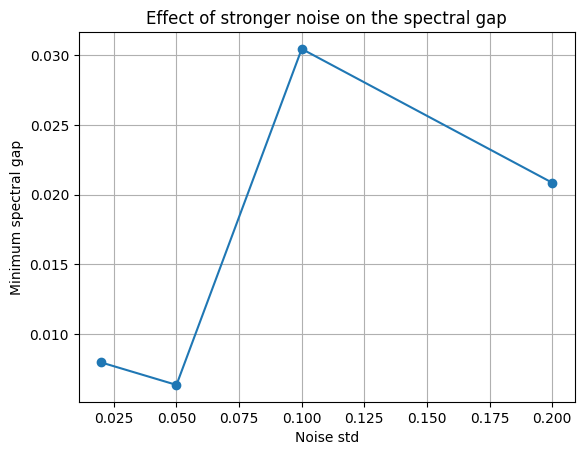

noise_std = 0.02 -> min gap = 0.007980
noise_std = 0.05 -> min gap = 0.006373
noise_std = 0.1 -> min gap = 0.030433
noise_std = 0.2 -> min gap = 0.020851


In [8]:
noise_levels = [0.02, 0.05, 0.1, 0.2]
min_gaps = []

for sigma in noise_levels:
    eig_hist_sigma, _ = sim.simulate_noisy_evolution(
        problem,
        nb_eigenvalues=5,
        noise_std=sigma,
        random_seed=42
    )
    eig_hist_sigma = np.array(eig_hist_sigma, dtype=float)
    gap_sigma = eig_hist_sigma[:, 1] - eig_hist_sigma[:, 0]
    min_gaps.append(gap_sigma.min())

plt.figure()
plt.plot(noise_levels, min_gaps, marker="o")
plt.xlabel("Noise std")
plt.ylabel("Minimum spectral gap")
plt.title("Effect of stronger noise on the spectral gap")
plt.grid(True)
plt.show()

for sigma, g in zip(noise_levels, min_gaps):
    print(f"noise_std = {sigma} -> min gap = {g:.6f}")

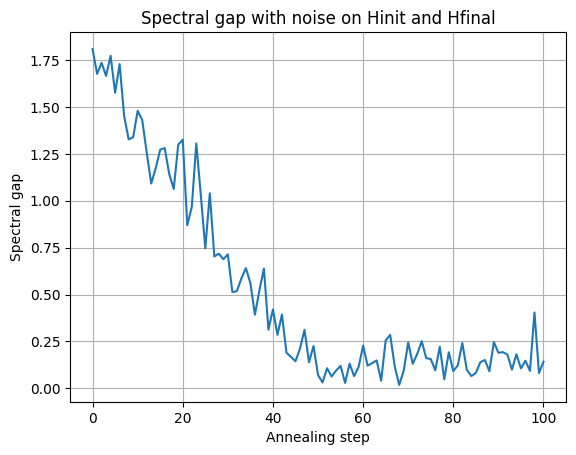

Minimum gap with noise on both Hinit and Hfinal: 0.018234519608318678


In [9]:
eig_hist_both, _ = sim.simulate_noisy_evolution_both(
    problem,
    nb_eigenvalues=5,
    noise_std_final=0.1,
    noise_std_init=0.1,
    random_seed=42
)

gap_both = sim.plot_spectral_gap(
    eig_hist_both,
    title="Spectral gap with noise on Hinit and Hfinal"
)

print("Minimum gap with noise on both Hinit and Hfinal:", gap_both.min())

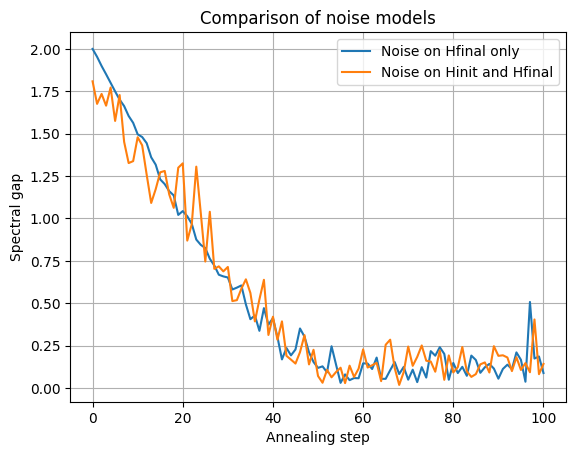

In [10]:
gap_final_only = np.array(eig_hist_noisy)[:, 1] - np.array(eig_hist_noisy)[:, 0]
gap_both = np.array(eig_hist_both)[:, 1] - np.array(eig_hist_both)[:, 0]

plt.figure()
plt.plot(gap_final_only, label="Noise on Hfinal only")
plt.plot(gap_both, label="Noise on Hinit and Hfinal")
plt.xlabel("Annealing step")
plt.ylabel("Spectral gap")
plt.title("Comparison of noise models")
plt.legend()
plt.grid(True)
plt.show()

Duplicated-node Ising instance:
0.8*x1*x2 - 4.0*x1*x3 + 0.5*x1 + 0.8*x2*x3 - 0.3*x2 + 0.5*x3


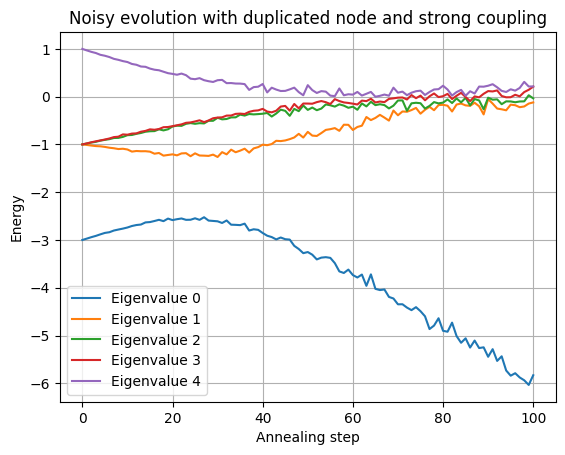

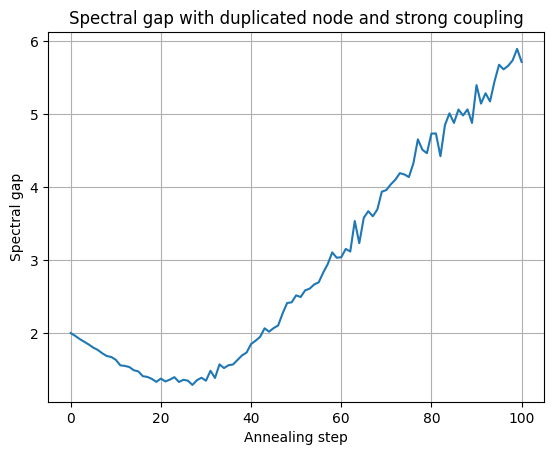

Minimum duplicated-node gap: 1.2894931762970772


In [11]:
duplicated_problem = sim.create_duplicated_node_instance(
    h1=0.5,
    h2=-0.3,
    j12=0.8,
    strong_coupling=-4.0
)

print("Duplicated-node Ising instance:")
print(duplicated_problem)

eig_hist_dup, _ = sim.simulate_noisy_evolution(
    duplicated_problem,
    nb_eigenvalues=5,
    noise_std=0.1,
    random_seed=42
)

sim.plot_eigenvalues(
    eig_hist_dup,
    title="Noisy evolution with duplicated node and strong coupling"
)

gap_dup = sim.plot_spectral_gap(
    eig_hist_dup,
    title="Spectral gap with duplicated node and strong coupling"
)

print("Minimum duplicated-node gap:", gap_dup.min())

## Discussion

In the noisy simulation, the five lowest eigenvalues still follow the global annealing trend, but the curves become irregular because noise perturbs the Hamiltonian at each time step.

At the beginning of the evolution, the noise is usually less visible because the system is still strongly dominated by the initial Hamiltonian and the energy scales are more clearly separated. As the evolution progresses and the spectral gap becomes smaller, the perturbations become more noticeable.

In general, noise tends to make the spectral gap less regular and can reduce it locally. This makes the system more sensitive to excitations and can make it harder to stay in the ground state during the annealing process.

When noise is added to both `Hinit` and `Hfinal`, the evolution is usually more disturbed than when only `Hfinal` is noisy. In that sense, adding noise on `Hinit` is generally worse for the stability of the process.

The simple noise model used here is useful for testing, but it is not fully representative of real quantum noise. A more realistic model would probably include correlations in time, non-Gaussian effects, hardware-dependent biases, and noise that does not affect all terms in the same way.

Finally, when the noise level becomes stronger, the spectral gap becomes more unstable and the annealing process becomes more difficult. Since the annealing time depends strongly on the gap, stronger noise generally worsens the resolution of the problem.